In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import root_mean_squared_error, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [ ]:
# We lezen hier de traindataset in.
data_train = pd.read_csv('data_train.csv')
data_train.head()

,Call Failure,Complaints,Subscription Length,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Age,Churn
0,4,0,29,6965,110,263,32,2,25,0
1,16,0,13,9158,175,70,38,5,55,0
2,4,0,32,7190,102,15,20,4,45,0
3,4,0,36,2900,25,5,16,3,30,0
4,0,0,35,148,4,29,4,5,55,0


In [3]:
# Numerieke kolommen en categorische kolommen waarbij het referentie niveau gedropt wordt.
numcols = ['Call Failure', 'Subscription Length', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS']
faccols = ['Age Group', 'Complaints']
droplevels = [1, 0]

In [ ]:
# We maken hier een pipeline aan met twee kolomtransformaties genaamd StandardScaler() en OneHotEncoder().
dataprep_rf = ColumnTransformer([
    ('numeriek', StandardScaler(), numcols),
    ('categorisch', OneHotEncoder(drop = droplevels, sparse_output=False), faccols),
], remainder = 'drop', verbose_feature_names_out = False)

dataprep_rf.set_output(transform = 'pandas')
dataprep_rf

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [ ]:
# We voegen hier random forest als model toe aan de pipeline.
pipeline_rf = Pipeline([
    ('preprocessing', dataprep_rf),
    ('model', RandomForestClassifier(
        warm_start = True,
        oob_score = roc_auc_score
    ))
])

pipeline_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [6]:
# We definieren hier een de respons en verklarende variabelen.
X_train = data_train.drop(columns = ['Churn'])
y_train = data_train['Churn']

# We fitten het model.
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [ ]:
oob_scores = []
n_estimators = 30

for i in range(1, n_estimators + 1, 1):
    pipeline_rf.set_params(model__n_estimators = i, model__warm_start = False)
    pipeline_rf.fit(X_train, y_train)
    oob_scores.append(pipeline_rf.named_steps['model'].oob_score_)

c:\Users\Timvc\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Timvc\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Timvc\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Timvc\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Timvc\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserW

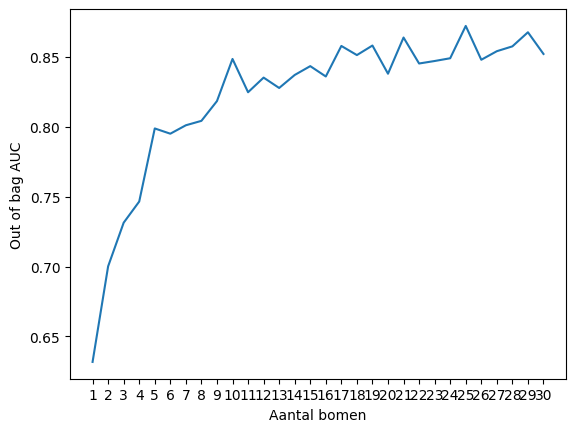

In [ ]:
# We plotten een grafiek waarbij de Out of Bag AUC wordt uitgezet tegen het aantal bomen om zo te bepalen welk aantal bomen men het beste kan gebruiken voor het fitten van de random forest.
sns.lineplot(x = range(1, n_estimators + 1, 1), y = oob_scores)
plt.xlabel('Aantal bomen')
plt.xticks(range(1, n_estimators + 1, 1))
plt.ylabel('Out of bag AUC')
plt.show()

In [ ]:
# We gaan hier random forests fitten. We kiezen ervoor om 20 bomen te fitten.
mtry = [2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40]
pipeline_rf.set_params(
    model__n_estimators = 20,
    model__warm_start = False
)
gridsearch_rf = GridSearchCV(
    pipeline_rf,
    param_grid = {'model__max_features': mtry},
    scoring = 'roc_auc',
    n_jobs = -2 
).fit(X_train, y_train)

In [ ]:
# We bepalen hier de waarde van het aantal variabelen om te gebruiken bij het fitten en de bijbehorende AUC-score.
best_m = gridsearch_rf.best_params_['model__max_features']
best_score = gridsearch_rf.best_score_

print(f'De beste waarde van m is {best_m} en de beste AUC-score is {best_score}.')

De beste waarde van m is 2 en de beste AUC-score is 0.971686497360138.


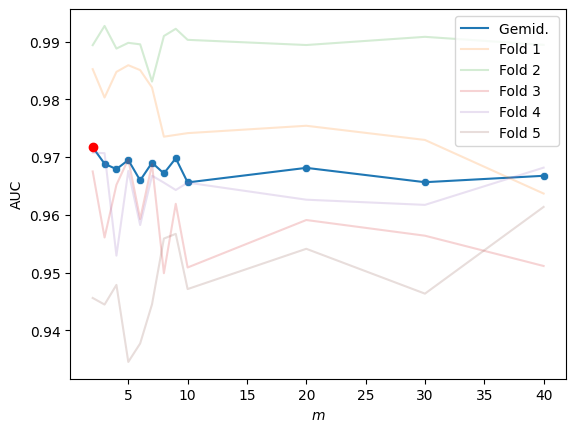

In [ ]:
# We plotten hier een grafiekje die de optiale waarde van m laat zien (rode punt in de onderstaande grafiek).
sns.lineplot(gridsearch_rf.cv_results_, x = 'param_model__max_features', y = 'mean_test_score', label = 'Gemid. ')
sns.scatterplot(gridsearch_rf.cv_results_, x = 'param_model__max_features', y = 'mean_test_score')
for i in range(5):
    sns.lineplot(gridsearch_rf.cv_results_, x = 'param_model__max_features', y = f'split{i}_test_score', alpha = 0.2, label = f'Fold {i+1}')
plt.plot(best_m, best_score, 'ro')
plt.xlabel('$m$')
plt.ylabel('AUC')
plt.legend(loc = 'upper right')
plt.show()

In [ ]:
best_model = gridsearch_rf.best_estimator_

vars = best_model.named_steps['preprocessing'].get_feature_names_out()
imps = best_model.named_steps['model'].feature_importances_

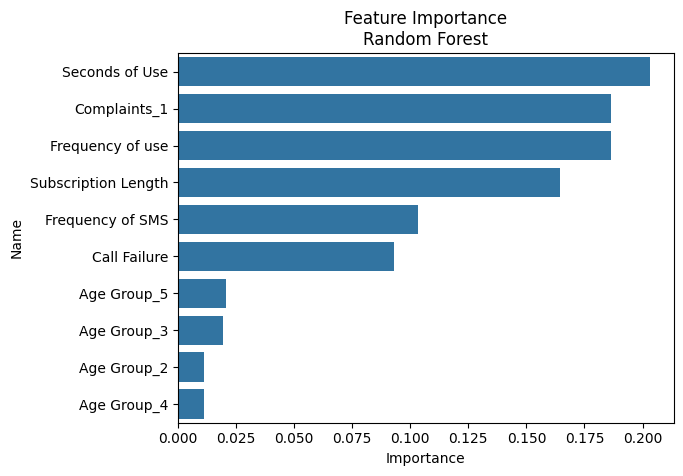

In [ ]:
# We plotten hier een staafdiagram om de belangrijkheid van de variabelen van de dataset te achterhalen.
imp_data = pd.DataFrame({'Name': vars, 'Importance': imps})
imp_data = imp_data.sort_values(by = 'Importance', ascending = False).iloc[:10]
sns.barplot(imp_data, y = 'Name', x = 'Importance')
plt.title('Feature Importance\nRandom Forest')
plt.show()

In [ ]:
# We berekenen hier de voorspellingen op de trainingsdata voor de out of bag voorspellingen.
p_pred = best_model.named_steps['model'].oob_decision_function_

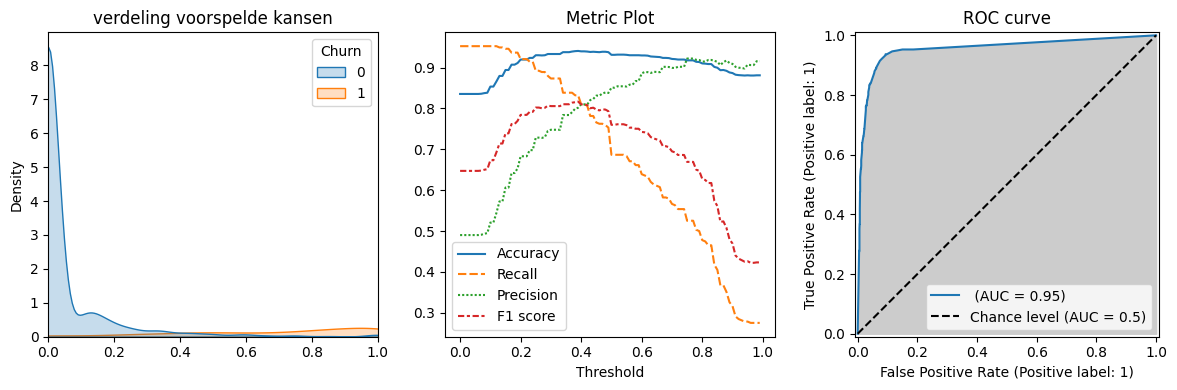

In [15]:
# We definieren hier een functie voor het maken van een pairplot betsaande uit een verdeling voorspelde kansen, een metric plot en een ROC curve.
def make_row(cr):
    return{
        'Accuracy': cr['accuracy'],
        'Recall': cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 score': cr['1']['f1-score']
    }

thresholds = np.arange(0, 1, 0.01)
plot_data = pd.DataFrame([
    make_row(classification_report(
        y_train,
        p_pred[:,1] > t,
        zero_division = True,
        output_dict = True
    )) for t in thresholds
])
plot_data.index = thresholds

plt.figure(figsize = (12,4), layout = 'tight')

# Plot 1
plt.subplot(1,3,1)
sns.kdeplot(data = data_train, x = p_pred[:,1], hue = 'Churn', fill = True)
plt.xlim(0,1)
plt.title('verdeling voorspelde kansen')

# Plot 2
nul_acc = []
plt.subplot(1,3,2)
sns.lineplot(plot_data)
plt.plot([0,1], [nul_acc, nul_acc], 'k:', alpha = 0.5, label = 'Nul Acc.')
plt.xlabel('Threshold')
plt.legend()
plt.title('Metric Plot')

# Plot 3
ax = plt.subplot(1,3,3)
roc = RocCurveDisplay.from_predictions(
    y_train,
    p_pred[:,1],
    name = '',
    plot_chance_level = True,
    ax = ax
)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()

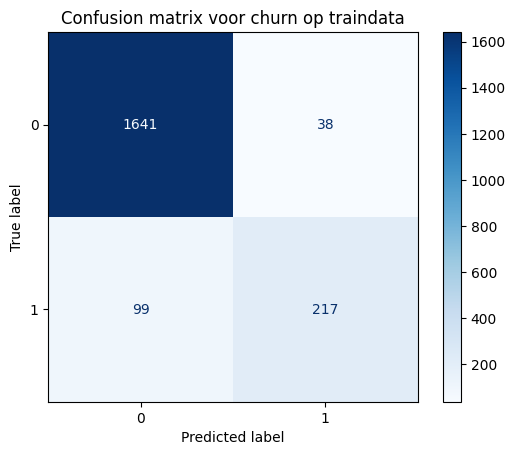

In [ ]:
# We maken hier een confusion matrix die het aantal klanten voorspelt die wel of niet hun abonnement opzeggen en die we dus een nieuw tarief moeten aanbieden.
y_pred = (p_pred[:, 1] > 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_train, y_pred, cmap = 'Blues')
plt.title('Confusion matrix voor churn op traindata')
plt.show()


In [32]:
# We berekenen hier de accuracy, recall, precision en F1-score als prestatiematen op basis van de verkregen confusion matrix.
accuracy = accuracy_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
f1score = f1_score(y_train, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Precision: {precision:.2f}")
print(f"F1-score: {f1score:.2f}")

Accuracy: 0.93
Recall: 0.69
Precision: 0.85
F1-score: 0.76
